# Best D4 Orbit-Reuploading Quantum Bottleneck for Model I

**Executed, self-contained architecture and paper report**

This notebook contains only the selected seed-2 hybrid quantum model used for three-class gravitational-lensing classification. It defines the exact model, strictly loads the frozen checkpoint, audits all parameters, performs a live CPU inference and D4-invariance check, recomputes the sealed official-test metrics, and generates paper-ready figures.

**Selected result:** 98.4746% development-validation accuracy and **98.3667% official-test accuracy** on 15,000 held-out images. The official-test prediction bundle was generated in the prospectively sealed v3 pass; this notebook analyzes that immutable bundle and does not tune on the test set.

The quantum circuit is evaluated with the exact differentiable PyTorch statevector implementation used for training. No optional quantum package is needed to reproduce the selected checkpoint.

## Reproducibility contract

- Classes: `axion`, `cdm`, `no_sub`.
- Development split: 70,021 training and 17,504 validation images, stratified with seed 42.
- Official test: 15,000 balanced images, exactly 5,000 per class.
- Model selection used development validation only.
- Selected checkpoint: seed 2, best epoch 19.
- Checkpoint, predictions, and result JSON are checked against fixed SHA-256 digests before analysis.
- Representative images are selected deterministically from the development-validation split. Official-test pixels are not opened for figure selection.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import os
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import torch
from IPython.display import display, Markdown

torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.manual_seed(2)
np.random.seed(2)

DATA_ROOT = Path(os.environ.get("DEEPLENSE_DATA_ROOT", "/home/jovyan/data"))
SEALED_MEMBER = DATA_ROOT / "outputs/deeplense-quantum/d4-orqb/model-i/locked/d4-orqb-model-i-v3-20260711-seal/members/q2"
OFFICIAL = DATA_ROOT / "outputs/deeplense-quantum/d4-orqb/model-i/locked/d4-orqb-model-i-v3-20260711-official-test"
CACHE = DATA_ROOT / "cache/d4-orqb/model_i_96_v1"
CHECKPOINT = SEALED_MEMBER / "best.pt"
VALIDATION_SUMMARY = SEALED_MEMBER / "summary.json"
HISTORY = SEALED_MEMBER / "history.json"
TEST_PREDICTIONS = OFFICIAL / "predictions/q2.npz"
TEST_RESULT = OFFICIAL / "result.json"
FIGURE_DIR = DATA_ROOT / "outputs/deeplense-quantum-paper-best-q2/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_SHA256 = {
    CHECKPOINT: "9b6bb5bab038b086c7e6dd3b0448de9fa204e6138e28da8bb13deb9374f87007",
    TEST_PREDICTIONS: "1479ffe28b950320166f913ed8dd53b0d9dceb4626faf79444ea17f9e96ae691",
    TEST_RESULT: "86b0b1df9cf33a772719799dd0d7632e81312e837c0de39e0003fc4e8ca83340",
}

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing = [str(path) for path in EXPECTED_SHA256 if not path.is_file()]
assert not missing, f"Missing required artifacts: {missing}"
observed_hashes = {str(path): sha256(path) for path in EXPECTED_SHA256}
for path, expected in EXPECTED_SHA256.items():
    assert observed_hashes[str(path)] == expected, f"SHA-256 mismatch: {path}"

CLASS_NAMES = ("Axion", "CDM", "No substructure")
COLORS = ("#6A5ACD", "#E45756", "#2A9D8F")
mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "device": "cpu",
    "artifact_hashes_verified": len(EXPECTED_SHA256),
    "paper_figure_directory": str(FIGURE_DIR),
})

{'python': '3.11.11', 'torch': '2.5.1+cu124', 'device': 'cpu', 'artifact_hashes_verified': 3, 'paper_figure_directory': '/home/jovyan/data/outputs/deeplense-quantum-paper-best-q2/figures'}


## Exact selected architecture

1. Each 96×96 intensity image is converted into eight fixed physics-informed maps: normalized intensity, log intensity, gradient magnitude, Laplacian magnitude, difference of local averages, radial gradient, tangential gradient, and a stabilized mixed derivative.
2. All eight elements of the dihedral group D4 are applied to the image. One shared MobileNet-style MBConv feature extractor produces a 128-dimensional descriptor for every orbit view.
3. A shared linear orbit projection maps each descriptor to two angle fields for each of four quantum heads, giving a tensor of shape `batch × 4 × 2 × 8`.
4. Each head is an eight-qubit circuit with two data reuploads. Every reupload performs dense RY/RZ data encoding, tied local RX/RY/RZ rotations, and symmetry-tied XX/ZZ interactions over complete D4 Cayley-edge orbits.
5. Local X/Z and pair XX/ZZ expectations are orbit-reduced into 12 invariant values per head, producing a 48-dimensional D4-invariant quantum bottleneck.
6. A compact prediction head maps the 48 invariants to three class logits.

The cell below is the complete minimal model definition. It contains only this selected path and preserves every checkpoint key exactly.

In [2]:
"""Standalone CPU inference definition for the winning seed-2 D4-ORQB.

This temporary source is intentionally restricted to the checkpoint's exact
base/tiny/angle/pair path.  It has no dependency on the repository package and
preserves every persistent ``state_dict`` key used by the 245,221-parameter
checkpoint.
"""

from __future__ import annotations

import math
from pathlib import Path
import sys
from typing import Any, Sequence

import torch
import torch.nn.functional as F
from torch import nn


DEFAULT_CHECKPOINT = Path(
    "/home/jovyan/data/outputs/deeplense-quantum/"
    "d4-orqb/model-i/fixed-backbone-replication/seed-2/quantum/best.pt"
)
CLASS_NAMES = ("axion", "cdm", "no_sub")

R_EDGES: tuple[tuple[int, int], ...] = (
    (0, 1),
    (0, 3),
    (1, 2),
    (2, 3),
    (4, 5),
    (4, 7),
    (5, 6),
    (6, 7),
)
R2_EDGES: tuple[tuple[int, int], ...] = ((0, 2), (1, 3), (4, 6), (5, 7))
S_EDGES: tuple[tuple[int, int], ...] = ((0, 4), (1, 7), (2, 6), (3, 5))


def norm2d(channels: int) -> nn.GroupNorm:
    groups = min(8, channels)
    while channels % groups:
        groups -= 1
    return nn.GroupNorm(groups, channels)


def d4_transform(
    images: torch.Tensor, rotation: int, reflected: int
) -> torch.Tensor:
    if reflected:
        images = torch.flip(images, dims=(-1,))
    return torch.rot90(images, rotation, dims=(-2, -1))


def d4_views(images: torch.Tensor) -> torch.Tensor:
    return torch.stack(
        [d4_transform(images, rotation, reflected) for reflected in (0, 1) for rotation in range(4)],
        dim=1,
    )


class PhysicsChannelBank(nn.Module):
    """The exact zero-parameter eight-channel base physics bank."""

    def __init__(
        self,
        log_gain: float = 20.0,
        epsilon: float = 1e-3,
        reference_pixels: int = 96,
    ) -> None:
        super().__init__()
        self.log_gain = float(log_gain)
        self.epsilon = float(epsilon)
        self.reference_pixels = int(reference_pixels)
        self.output_channels = 8
        sobel_x = torch.tensor(
            [[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]]
        ) / 8.0
        sobel_y = sobel_x.transpose(0, 1).contiguous()
        laplacian = torch.tensor(
            [[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]]
        )
        self.register_buffer(
            "sobel_x", sobel_x.view(1, 1, 3, 3), persistent=False
        )
        self.register_buffer(
            "sobel_y", sobel_y.view(1, 1, 3, 3), persistent=False
        )
        self.register_buffer(
            "laplacian", laplacian.view(1, 1, 3, 3), persistent=False
        )

    @staticmethod
    def _conv_reflect(images: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
        return F.conv2d(F.pad(images, (1, 1, 1, 1), mode="reflect"), kernel)

    @staticmethod
    def _avg_reflect(images: torch.Tensor, kernel_size: int) -> torch.Tensor:
        pad = kernel_size // 2
        return F.avg_pool2d(
            F.pad(images, (pad, pad, pad, pad), mode="reflect"),
            kernel_size=kernel_size,
            stride=1,
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        images = torch.nan_to_num(
            images.float(), nan=0.0, posinf=0.0, neginf=0.0
        ).clamp_min(0.0)
        scale = images.amax(dim=(-2, -1), keepdim=True).clamp_min(1e-6)
        images = (images / scale).clamp(0.0, 1.0)
        log_intensity = torch.log1p(self.log_gain * images) / math.log1p(
            self.log_gain
        )

        gradient_x = self._conv_reflect(log_intensity, self.sobel_x)
        gradient_y = self._conv_reflect(log_intensity, self.sobel_y)
        pixel_scale = float(images.shape[-1]) / self.reference_pixels
        gradient = torch.sqrt(
            gradient_x.square() + gradient_y.square() + 1e-8
        ) * pixel_scale
        laplacian = (
            self._conv_reflect(log_intensity, self.laplacian).abs()
            * pixel_scale**2
        )
        small_kernel = max(3, int(round(3 * pixel_scale)) | 1)
        large_kernel = max(
            small_kernel + 2, int(round(9 * pixel_scale)) | 1
        )
        difference_of_averages = (
            self._avg_reflect(log_intensity, small_kernel)
            - self._avg_reflect(log_intensity, large_kernel)
        ).abs()

        height, width = images.shape[-2:]
        yy = torch.linspace(
            -1.0, 1.0, height, device=images.device, dtype=images.dtype
        )
        xx = torch.linspace(
            -1.0, 1.0, width, device=images.device, dtype=images.dtype
        )
        grid_y, grid_x = torch.meshgrid(yy, xx, indexing="ij")
        radius = torch.sqrt(grid_x.square() + grid_y.square()).clamp_min(1e-4)
        unit_x = (grid_x / radius).view(1, 1, height, width)
        unit_y = (grid_y / radius).view(1, 1, height, width)
        radial = (
            gradient_x * unit_x + gradient_y * unit_y
        ).abs() * pixel_scale
        tangential = (
            -gradient_x * unit_y + gradient_y * unit_x
        ).abs() * pixel_scale

        log_ratio_squared = torch.log(
            (1.0 + self.epsilon) / (images + self.epsilon)
        ).square()
        mixed = self._conv_reflect(
            self._conv_reflect(log_ratio_squared, self.sobel_x), self.sobel_y
        ).abs() * pixel_scale**2
        return torch.cat(
            (
                images,
                log_intensity,
                torch.tanh(2.0 * gradient),
                torch.tanh(laplacian),
                torch.tanh(4.0 * difference_of_averages),
                torch.tanh(2.0 * radial),
                torch.tanh(2.0 * tangential),
                torch.tanh(mixed),
            ),
            dim=1,
        )


class SqueezeExcite(nn.Module):
    def __init__(self, channels: int, reduction: int = 4) -> None:
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Hardsigmoid(inplace=True),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return features * self.net(features)


class MBConv(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        expand: int,
        stride: int,
        kernel_size: int = 5,
    ) -> None:
        super().__init__()
        hidden = in_channels * expand
        layers: list[nn.Module] = []
        if hidden != in_channels:
            layers.extend(
                (
                    nn.Conv2d(in_channels, hidden, 1, bias=False),
                    norm2d(hidden),
                    nn.SiLU(inplace=True),
                )
            )
        layers.extend(
            (
                nn.Conv2d(
                    hidden,
                    hidden,
                    kernel_size,
                    stride=stride,
                    padding=kernel_size // 2,
                    groups=hidden,
                    bias=False,
                ),
                norm2d(hidden),
                nn.SiLU(inplace=True),
                SqueezeExcite(hidden),
                nn.Conv2d(hidden, out_channels, 1, bias=False),
                norm2d(out_channels),
            )
        )
        self.block = nn.Sequential(*layers)
        self.use_residual = stride == 1 and in_channels == out_channels

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        output = self.block(features)
        return features + output if self.use_residual else output


class TinyOrbitEncoder(nn.Module):
    """The exact tiny encoder topology and checkpoint module names."""

    output_dim = 128

    def __init__(self, input_channels: int = 8) -> None:
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(
                input_channels, 16, 5, stride=2, padding=2, bias=False
            ),
            norm2d(16),
            nn.SiLU(inplace=True),
        )
        specifications = (
            (16, 24, 2, 2),
            (24, 24, 2, 1),
            (24, 40, 3, 2),
            (40, 40, 3, 1),
            (40, 64, 3, 2),
            (64, 64, 3, 1),
            (64, 96, 3, 2),
            (96, 96, 2, 1),
        )
        self.blocks = nn.Sequential(
            *(
                MBConv(in_channels, out_channels, expand, stride)
                for in_channels, out_channels, expand, stride in specifications
            )
        )
        self.final = nn.Sequential(
            nn.Conv2d(96, self.output_dim, 1, bias=False),
            norm2d(self.output_dim),
            nn.SiLU(inplace=True),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        features = self.stem(features)
        features = self.blocks(features)
        features = self.final(features)
        return features.mean(dim=(-2, -1))


def _bit_mask(qubit: int, n_qubits: int) -> int:
    return 1 << (n_qubits - qubit - 1)


def _apply_ry(
    state: torch.Tensor, theta: torch.Tensor, qubit: int, n_qubits: int
) -> torch.Tensor:
    left = 1 << qubit
    right = 1 << (n_qubits - qubit - 1)
    view = state.reshape(state.shape[0], left, 2, right)
    amplitude_0, amplitude_1 = view[:, :, 0, :], view[:, :, 1, :]
    cosine = torch.cos(theta / 2).view(-1, 1, 1)
    sine = torch.sin(theta / 2).view(-1, 1, 1)
    output = torch.stack(
        (
            cosine * amplitude_0 - sine * amplitude_1,
            sine * amplitude_0 + cosine * amplitude_1,
        ),
        dim=2,
    )
    return output.reshape_as(state)


def _apply_rx(
    state: torch.Tensor, theta: torch.Tensor, qubit: int, n_qubits: int
) -> torch.Tensor:
    left = 1 << qubit
    right = 1 << (n_qubits - qubit - 1)
    view = state.reshape(state.shape[0], left, 2, right)
    amplitude_0, amplitude_1 = view[:, :, 0, :], view[:, :, 1, :]
    cosine = torch.cos(theta / 2).view(-1, 1, 1)
    sine = (-1j * torch.sin(theta / 2)).view(-1, 1, 1)
    output = torch.stack(
        (
            cosine * amplitude_0 + sine * amplitude_1,
            sine * amplitude_0 + cosine * amplitude_1,
        ),
        dim=2,
    )
    return output.reshape_as(state)


def _apply_rz(
    state: torch.Tensor, theta: torch.Tensor, qubit: int, n_qubits: int
) -> torch.Tensor:
    left = 1 << qubit
    right = 1 << (n_qubits - qubit - 1)
    view = state.reshape(state.shape[0], left, 2, right)
    phase_0 = torch.exp(-0.5j * theta).view(-1, 1, 1)
    phase_1 = torch.exp(0.5j * theta).view(-1, 1, 1)
    output = torch.stack(
        (phase_0 * view[:, :, 0, :], phase_1 * view[:, :, 1, :]), dim=2
    )
    return output.reshape_as(state)


def _apply_pair_rotation(
    state: torch.Tensor,
    theta: torch.Tensor,
    qubit_0: int,
    qubit_1: int,
    pauli: str,
    z_signs: torch.Tensor,
) -> torch.Tensor:
    cosine = torch.cos(theta / 2).view(-1, 1)
    sine = (-1j * torch.sin(theta / 2)).view(-1, 1)
    if pauli == "z":
        transformed = state * (
            z_signs[qubit_0] * z_signs[qubit_1]
        ).view(1, -1)
    elif pauli == "x":
        mask = _bit_mask(qubit_0, z_signs.shape[0]) | _bit_mask(
            qubit_1, z_signs.shape[0]
        )
        permutation = torch.arange(state.shape[1], device=state.device) ^ mask
        transformed = state.index_select(1, permutation)
    else:
        raise ValueError(f"Unsupported Pauli operator: {pauli}")
    return cosine * state + sine * transformed


def _edge_expectation_z(
    probabilities: torch.Tensor,
    z_signs: torch.Tensor,
    edges: Sequence[tuple[int, int]],
) -> torch.Tensor:
    observables = torch.stack([z_signs[a] * z_signs[b] for a, b in edges])
    return probabilities @ observables.transpose(0, 1)


def _expectation_x(
    state: torch.Tensor,
    qubits: Sequence[tuple[int, ...]],
    n_qubits: int,
) -> torch.Tensor:
    values: list[torch.Tensor] = []
    basis = torch.arange(state.shape[1], device=state.device)
    for wires in qubits:
        mask = 0
        for wire in wires:
            mask |= _bit_mask(wire, n_qubits)
        flipped = state.index_select(1, basis ^ mask)
        values.append((state.conj() * flipped).sum(dim=1).real)
    return torch.stack(values, dim=1)


class D4OrbitQuantumBottleneck(nn.Module):
    """The exact four-head/two-reupload angle/pair quantum core."""

    parameters_per_layer = 11
    invariants_per_head = 12

    def __init__(self) -> None:
        super().__init__()
        self.heads = 4
        self.reuploads = 2
        self.n_qubits = 8
        parameters = torch.zeros(
            self.heads, self.reuploads, self.parameters_per_layer
        )
        parameters[..., 0] = 1.0
        parameters[..., 2] = 1.0
        parameters[..., 4:] = 0.02 * torch.randn_like(parameters[..., 4:])
        self.params = nn.Parameter(parameters)

        basis = torch.arange(1 << self.n_qubits)
        signs = []
        for qubit in range(self.n_qubits):
            bit = (basis & _bit_mask(qubit, self.n_qubits)) != 0
            signs.append(
                torch.where(
                    bit, -torch.ones_like(basis), torch.ones_like(basis)
                )
            )
        self.register_buffer(
            "z_signs", torch.stack(signs).float(), persistent=False
        )
        self.register_buffer(
            "r_edges", torch.tensor(R_EDGES, dtype=torch.long), persistent=False
        )
        self.register_buffer(
            "r2_edges",
            torch.tensor(R2_EDGES, dtype=torch.long),
            persistent=False,
        )
        self.register_buffer(
            "s_edges", torch.tensor(S_EDGES, dtype=torch.long), persistent=False
        )

    @property
    def output_dim(self) -> int:
        return self.heads * self.invariants_per_head

    def _edge_rotation(
        self,
        state: torch.Tensor,
        theta: torch.Tensor,
        edges: torch.Tensor,
        pauli: str,
    ) -> torch.Tensor:
        for qubit_0, qubit_1 in edges.tolist():
            state = _apply_pair_rotation(
                state,
                theta,
                qubit_0,
                qubit_1,
                pauli,
                self.z_signs,
            )
        return state

    def _run_statevector(self, orbit_features: torch.Tensor) -> torch.Tensor:
        batch = orbit_features.shape[0]
        features = orbit_features.reshape(
            batch * self.heads, 2, self.n_qubits
        ).float()
        parameters = self.params.unsqueeze(0).expand(batch, -1, -1, -1)
        parameters = parameters.reshape(
            batch * self.heads, self.reuploads, self.parameters_per_layer
        ).float()
        state = torch.zeros(
            features.shape[0],
            1 << self.n_qubits,
            dtype=torch.complex64,
            device=features.device,
        )
        state[:, 0] = 1.0 + 0.0j

        for layer in range(self.reuploads):
            layer_parameters = parameters[:, layer]
            for qubit in range(self.n_qubits):
                ry_angle = (
                    layer_parameters[:, 0] * features[:, 0, qubit]
                    + layer_parameters[:, 1]
                )
                rz_angle = (
                    layer_parameters[:, 2] * features[:, 1, qubit]
                    + layer_parameters[:, 3]
                )
                state = _apply_ry(state, ry_angle, qubit, self.n_qubits)
                state = _apply_rz(state, rz_angle, qubit, self.n_qubits)
            for qubit in range(self.n_qubits):
                state = _apply_rx(
                    state, layer_parameters[:, 4], qubit, self.n_qubits
                )
                state = _apply_ry(
                    state, layer_parameters[:, 5], qubit, self.n_qubits
                )
                state = _apply_rz(
                    state, layer_parameters[:, 6], qubit, self.n_qubits
                )
            state = self._edge_rotation(
                state, layer_parameters[:, 7], self.r_edges, "z"
            )
            state = self._edge_rotation(
                state, layer_parameters[:, 8], self.s_edges, "z"
            )
            state = self._edge_rotation(
                state, layer_parameters[:, 9], self.r_edges, "x"
            )
            state = self._edge_rotation(
                state, layer_parameters[:, 10], self.s_edges, "x"
            )
        return state

    def forward(
        self, orbit_features: torch.Tensor, return_equivariant: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, dict[str, torch.Tensor]]:
        expected_shape = (self.heads, 2, self.n_qubits)
        if orbit_features.ndim != 4 or orbit_features.shape[1:] != expected_shape:
            raise ValueError(
                f"Expected (B,{self.heads},2,{self.n_qubits}), "
                f"got {tuple(orbit_features.shape)}"
            )
        with torch.autocast(
            device_type=orbit_features.device.type, enabled=False
        ):
            state = self._run_statevector(orbit_features)
            probabilities = state.abs().square()
            z_values = probabilities @ self.z_signs.transpose(0, 1)
            x_values = _expectation_x(
                state,
                [(qubit,) for qubit in range(self.n_qubits)],
                self.n_qubits,
            )
            edge_families = (R_EDGES, R2_EDGES, S_EDGES)
            zz_values = tuple(
                _edge_expectation_z(probabilities, self.z_signs, edges)
                for edges in edge_families
            )
            xx_values = tuple(
                _expectation_x(state, edges, self.n_qubits)
                for edges in edge_families
            )

            def edge_products(
                values: torch.Tensor, edges: Sequence[tuple[int, int]]
            ) -> torch.Tensor:
                return torch.stack(
                    [values[:, a] * values[:, b] for a, b in edges], dim=1
                )

            z_mean = z_values.mean(dim=1)
            x_mean = x_values.mean(dim=1)
            invariants = torch.stack(
                (
                    z_mean,
                    z_values.square().mean(dim=1) - z_mean.square(),
                    x_mean,
                    x_values.square().mean(dim=1) - x_mean.square(),
                    *(values.mean(dim=1) for values in zz_values),
                    *(values.mean(dim=1) for values in xx_values),
                    (
                        zz_values[0] - edge_products(z_values, R_EDGES)
                    ).mean(dim=1),
                    (
                        xx_values[0] - edge_products(x_values, R_EDGES)
                    ).mean(dim=1),
                ),
                dim=1,
            ).reshape(orbit_features.shape[0], self.output_dim)
        if not return_equivariant:
            return invariants
        return invariants, {
            "z": z_values.reshape(
                orbit_features.shape[0], self.heads, self.n_qubits
            ),
            "x": x_values.reshape(
                orbit_features.shape[0], self.heads, self.n_qubits
            ),
        }


class BestD4ORQB(nn.Module):
    """Exact 245,221-parameter seed-2 base/tiny D4-ORQB architecture."""

    def __init__(self) -> None:
        super().__init__()
        self.physics = PhysicsChannelBank()
        self.encoder = TinyOrbitEncoder(input_channels=8)
        self.orbit_projection = nn.Linear(128, 8)
        self.core = D4OrbitQuantumBottleneck()
        self.head = nn.Sequential(
            nn.LayerNorm(48),
            nn.Linear(48, 32),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),
            nn.Linear(32, 3),
        )

    @property
    def parameter_count(self) -> int:
        return sum(parameter.numel() for parameter in self.parameters())

    def orbit_encode(
        self, images: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        views = d4_views(images)
        batch, group, channels, height, width = views.shape
        flattened_views = views.reshape(
            batch * group, channels, height, width
        )
        physics = self.physics(flattened_views)
        encoded_flat = self.encoder(physics)
        encoded = encoded_flat.reshape(batch, group, 128)
        projected = self.orbit_projection(encoded_flat)
        projected = projected.reshape(batch, group, 4, 2).permute(0, 2, 3, 1)
        angles = math.pi * torch.tanh(projected)
        return encoded, angles

    def forward(
        self, images: torch.Tensor, return_aux: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, dict[str, Any]]:
        encoded, angles = self.orbit_encode(images)
        if return_aux:
            invariants, equivariant = self.core(
                angles, return_equivariant=True
            )
        else:
            invariants = self.core(angles)
            equivariant = None
        logits = self.head(invariants)
        if not return_aux:
            return logits
        return logits, {
            "encoded": encoded,
            "angles": angles,
            "invariants": invariants,
            "equivariant": equivariant,
        }

    @classmethod
    def from_checkpoint(
        cls,
        checkpoint_path: str | Path = DEFAULT_CHECKPOINT,
        *,
        map_location: str | torch.device = "cpu",
    ) -> tuple["BestD4ORQB", dict[str, Any]]:
        checkpoint_path = Path(checkpoint_path)
        try:
            payload = torch.load(
                checkpoint_path,
                map_location=map_location,
                weights_only=True,
            )
        except TypeError:  # Compatibility with older PyTorch releases.
            payload = torch.load(checkpoint_path, map_location=map_location)
        if not isinstance(payload, dict) or "model" not in payload:
            raise ValueError(
                "Expected a checkpoint wrapper containing the 'model' state_dict"
            )
        model = cls()
        model.load_state_dict(payload["model"], strict=True)
        model.eval()
        return model, payload


def _self_test(checkpoint_path: str | Path) -> None:
    torch.set_num_threads(min(torch.get_num_threads(), 4))
    model, payload = BestD4ORQB.from_checkpoint(checkpoint_path)
    assert model.parameter_count == 245_221, model.parameter_count
    assert tuple(model.core.params.shape) == (4, 2, 11)
    image = torch.linspace(0.0, 1.0, 96 * 96, dtype=torch.float32).reshape(
        1, 1, 96, 96
    )
    with torch.inference_mode():
        logits, auxiliary = model(image, return_aux=True)
    assert tuple(logits.shape) == (1, 3)
    assert tuple(auxiliary["angles"].shape) == (1, 4, 2, 8)
    assert tuple(auxiliary["invariants"].shape) == (1, 48)
    assert bool(torch.isfinite(logits).all())
    print(
        {
            "status": "passed",
            "checkpoint": str(Path(checkpoint_path).resolve()),
            "checkpoint_epoch": int(payload.get("epoch", -1)),
            "parameters": model.parameter_count,
            "logits_shape": list(logits.shape),
            "angles_shape": list(auxiliary["angles"].shape),
            "invariants_shape": list(auxiliary["invariants"].shape),
            "probabilities": torch.softmax(logits, dim=1).tolist(),
        }
    )

In [3]:
model, checkpoint_payload = BestD4ORQB.from_checkpoint(CHECKPOINT)
CLASS_NAMES = ("Axion", "CDM", "No substructure")
assert checkpoint_payload["epoch"] == 19
assert model.parameter_count == 245_221

parameter_breakdown = {
    "Physics feature bank": sum(p.numel() for p in model.physics.parameters()),
    "Shared feature extractor": sum(p.numel() for p in model.encoder.parameters()),
    "Orbit-to-angle projection": sum(p.numel() for p in model.orbit_projection.parameters()),
    "Quantum circuit": sum(p.numel() for p in model.core.parameters()),
    "Prediction head": sum(p.numel() for p in model.head.parameters()),
}
assert sum(parameter_breakdown.values()) == 245_221
assert parameter_breakdown["Quantum circuit"] == 88

parameter_rows = [
    (name, value, 100 * value / model.parameter_count)
    for name, value in parameter_breakdown.items()
]
parameter_markdown = ["| Component | Trainable parameters | Share |", "|---|---:|---:|"]
parameter_markdown.extend(
    f"| {name} | {value:,} | {share:.4f}% |"
    for name, value, share in parameter_rows
)
display(Markdown("\n".join(parameter_markdown)))
print("Strict checkpoint load: PASSED")
print("Circuit tensor:", tuple(model.core.params.shape), "= 4 heads × 2 reuploads × 11 tied parameters")

| Component | Trainable parameters | Share |
|---|---:|---:|
| Physics feature bank | 0 | 0.0000% |
| Shared feature extractor | 242,338 | 98.8243% |
| Orbit-to-angle projection | 1,032 | 0.4208% |
| Quantum circuit | 88 | 0.0359% |
| Prediction head | 1,763 | 0.7189% |

Strict checkpoint load: PASSED
Circuit tensor: (4, 2, 11) = 4 heads × 2 reuploads × 11 tied parameters


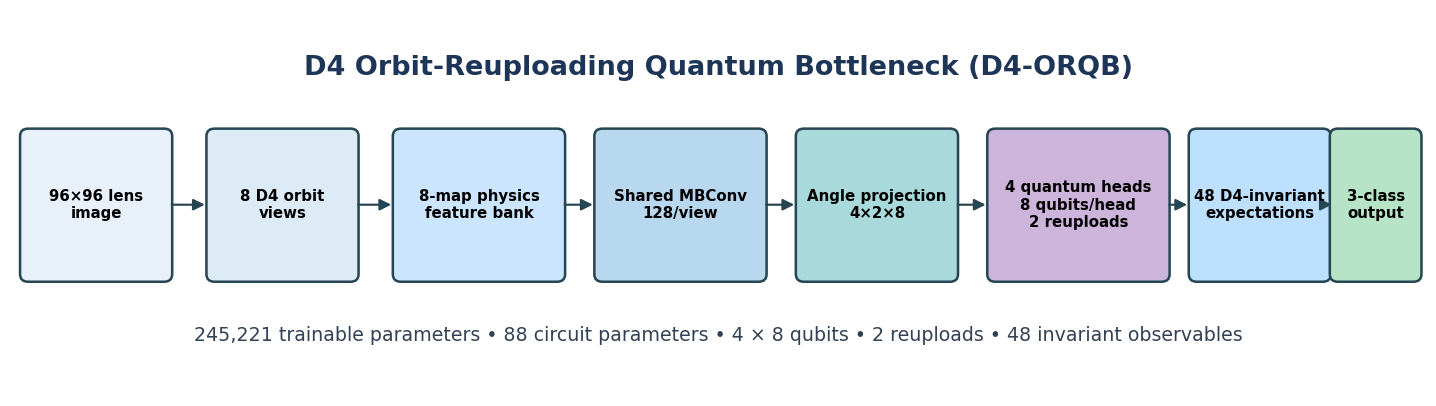

In [4]:
def save_paper_figure(fig, stem: str):
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")
blocks = [
    (0.15, "96×96 lens\nimage", "#E8F1FA"),
    (2.0, "8 D4 orbit\nviews", "#DDEBF7"),
    (3.85, "8-map physics\nfeature bank", "#CCE5FF"),
    (5.85, "Shared MBConv\n128/view", "#B8D8F0"),
    (7.85, "Angle projection\n4×2×8", "#A8DADC"),
    (9.75, "4 quantum heads\n8 qubits/head\n2 reuploads", "#CDB4DB"),
    (11.75, "48 D4-invariant\nexpectations", "#BDE0FE"),
    (13.15, "3-class\noutput", "#B7E4C7"),
]
widths = [1.35, 1.35, 1.55, 1.55, 1.45, 1.65, 1.25, 0.75]
for i, ((x, label, color), width) in enumerate(zip(blocks, widths)):
    box = FancyBboxPatch((x, 1.25), width, 1.45, boxstyle="round,pad=0.08",
                         linewidth=1.4, edgecolor="#264653", facecolor=color)
    ax.add_patch(box)
    ax.text(x + width/2, 1.98, label, ha="center", va="center", fontsize=8.3, weight="bold")
    if i < len(blocks) - 1:
        nx = blocks[i+1][0]
        ax.add_patch(FancyArrowPatch((x + width + .04, 1.98), (nx - .06, 1.98),
                                     arrowstyle="-|>", mutation_scale=13, linewidth=1.2,
                                     color="#264653"))
ax.text(7.0, 3.35, "D4 Orbit-Reuploading Quantum Bottleneck (D4-ORQB)",
        ha="center", fontsize=15, weight="bold", color="#1D3557")
ax.text(7.0, .55, "245,221 trainable parameters • 88 circuit parameters • 4 × 8 qubits • 2 reuploads • 48 invariant observables",
        ha="center", fontsize=10.5, color="#334155")
save_paper_figure(fig, "fig01_d4_orqb_architecture")

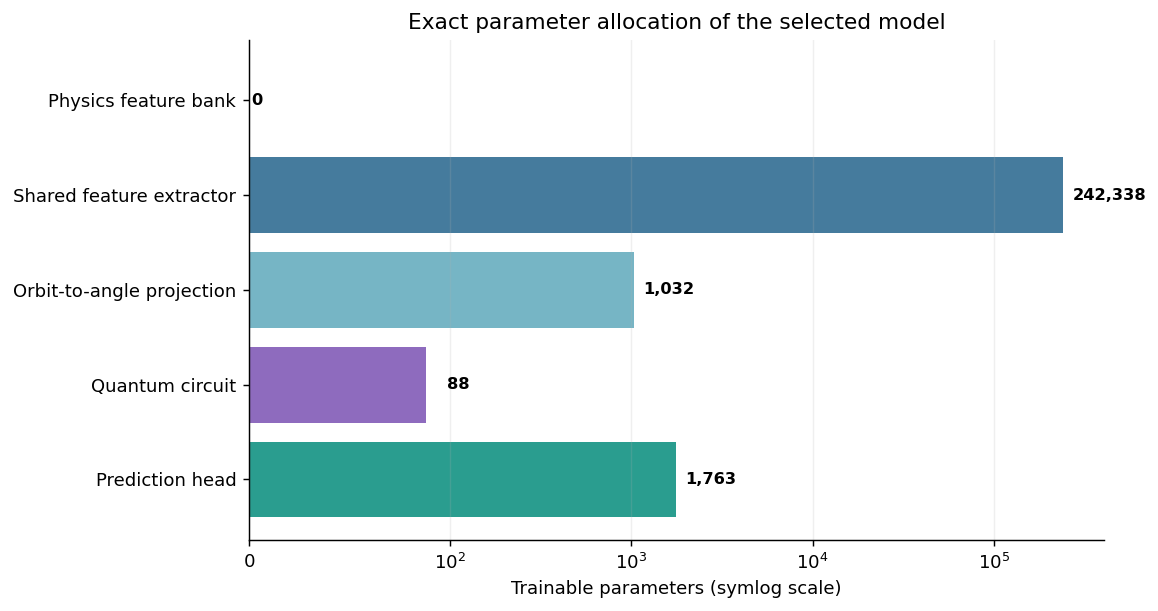

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
names = list(parameter_breakdown)
values = np.array(list(parameter_breakdown.values()))
y = np.arange(len(names))
bars = ax.barh(y, values, color=["#CBD5E1", "#457B9D", "#76B5C5", "#8E6BBE", "#2A9D8F"])
ax.set_xscale("symlog", linthresh=100)
ax.set_yticks(y, names)
ax.invert_yaxis()
ax.set_xlabel("Trainable parameters (symlog scale)")
ax.set_title("Exact parameter allocation of the selected model")
for bar, value in zip(bars, values):
    ax.text(max(value, 1) * 1.12, bar.get_y() + bar.get_height()/2,
            f"{value:,}", va="center", fontsize=9, weight="bold")
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig02_parameter_allocation")

## Live checkpoint inference and exact D4-invariance check

The next cells use deterministic examples from the development-validation split. This verifies that the notebook's standalone implementation loads the selected weights, produces finite outputs, and remains invariant under all eight D4 transformations.

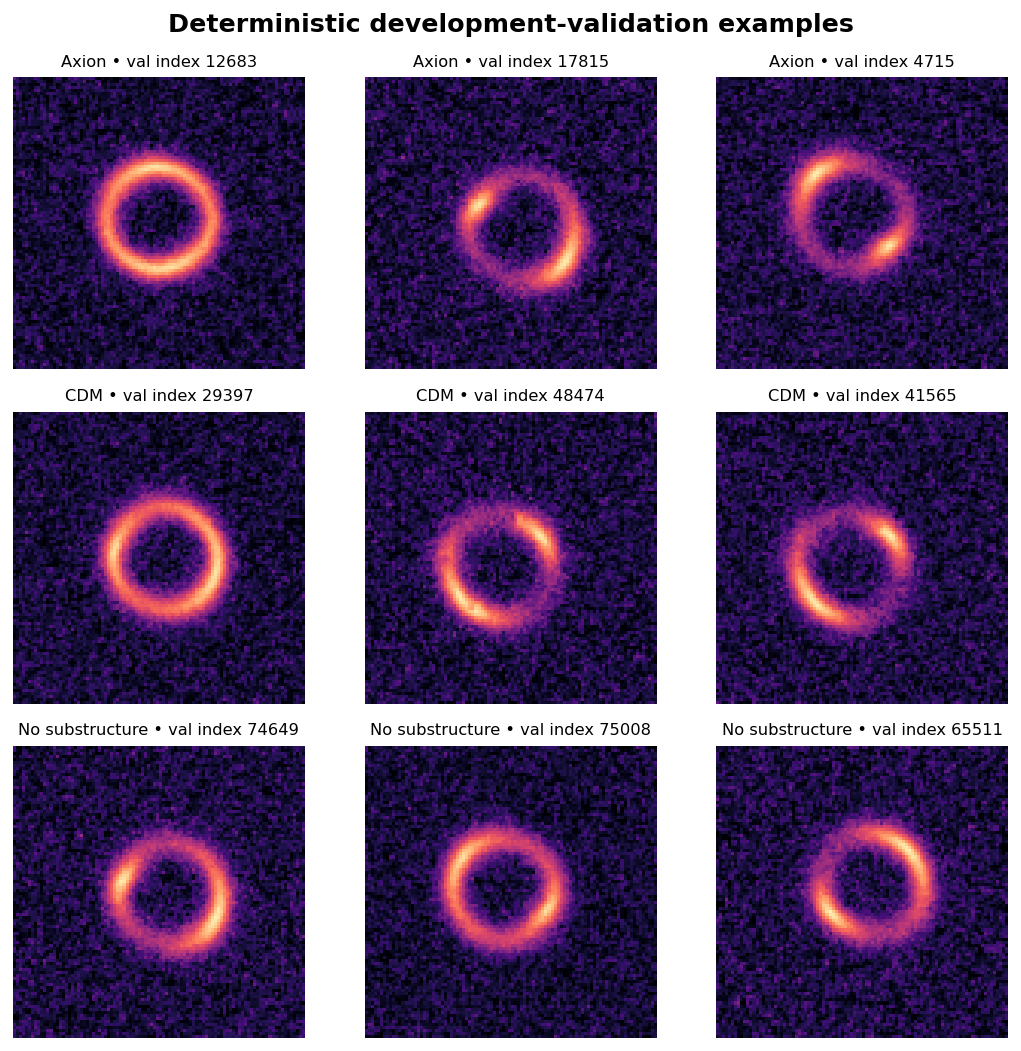

In [6]:
development_images = np.load(CACHE / "development/images.npy", mmap_mode="r")
development_labels = np.load(CACHE / "development/labels.npy", mmap_mode="r")
split = np.load(CACHE / "split_seed42_val0.2000.npz")
validation_indices = split["val"]

selected_indices = {
    label: validation_indices[development_labels[validation_indices] == label][:3]
    for label in range(3)
}

def display_transform(image):
    image = np.asarray(image, dtype=np.float32)
    return np.log1p(30 * np.clip(image, 0, None)) / np.log(31)

fig, axes = plt.subplots(3, 3, figsize=(8.3, 8.2))
for label, row in selected_indices.items():
    for col, index in enumerate(row):
        axes[label, col].imshow(display_transform(development_images[index]), cmap="magma", vmin=0, vmax=1)
        axes[label, col].set_title(f"{CLASS_NAMES[label]} • val index {int(index)}", fontsize=9)
        axes[label, col].axis("off")
fig.suptitle("Deterministic development-validation examples", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig03_development_lens_examples")

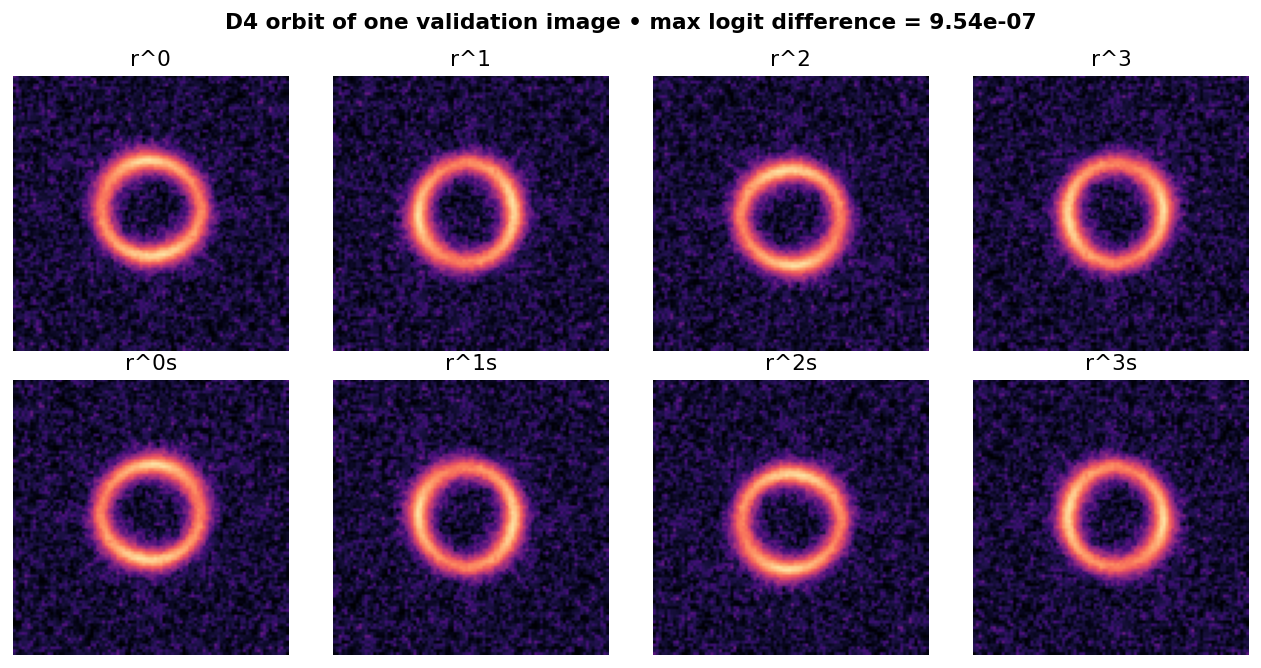

{'live_prediction': 'Axion', 'live_probabilities': {'Axion': 0.9895753860473633, 'CDM': 0.0025706004817038774, 'No substructure': 0.007853946648538113}, 'angles_shape': (1, 4, 2, 8), 'invariants_shape': (1, 48), 'maximum_D4_logit_difference': 9.5367431640625e-07}


In [7]:
reference_index = int(selected_indices[0][0])
reference_np = np.asarray(development_images[reference_index], dtype=np.float32)
reference = torch.tensor(reference_np.tolist(), dtype=torch.float32)[None, None]
orbit_batch = torch.cat([
    d4_transform(reference, rotation, reflected)
    for reflected in (0, 1) for rotation in range(4)
], dim=0)

with torch.inference_mode():
    logits, auxiliary = model(reference, return_aux=True)
    orbit_logits = model(orbit_batch)
    orbit_probabilities = torch.softmax(orbit_logits, dim=1)

assert tuple(auxiliary["angles"].shape) == (1, 4, 2, 8)
assert tuple(auxiliary["invariants"].shape) == (1, 48)
max_logit_difference = float((orbit_logits - orbit_logits[:1]).abs().max())
assert max_logit_difference < 2e-5

fig, axes = plt.subplots(2, 4, figsize=(10, 5.2))
for i, ax in enumerate(axes.flat):
    orbit_image = np.asarray(orbit_batch[i, 0].tolist(), dtype=np.float32)
    ax.imshow(display_transform(orbit_image), cmap="magma", vmin=0, vmax=1)
    transform_name = f"r^{i % 4}" + ("s" if i >= 4 else "")
    ax.set_title(transform_name)
    ax.axis("off")
fig.suptitle(f"D4 orbit of one validation image • max logit difference = {max_logit_difference:.2e}",
             fontsize=12, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig04_d4_orbit_invariance")

print({
    "live_prediction": CLASS_NAMES[int(logits.argmax(1))],
    "live_probabilities": dict(zip(CLASS_NAMES, torch.softmax(logits, 1)[0].tolist())),
    "angles_shape": tuple(auxiliary["angles"].shape),
    "invariants_shape": tuple(auxiliary["invariants"].shape),
    "maximum_D4_logit_difference": max_logit_difference,
})

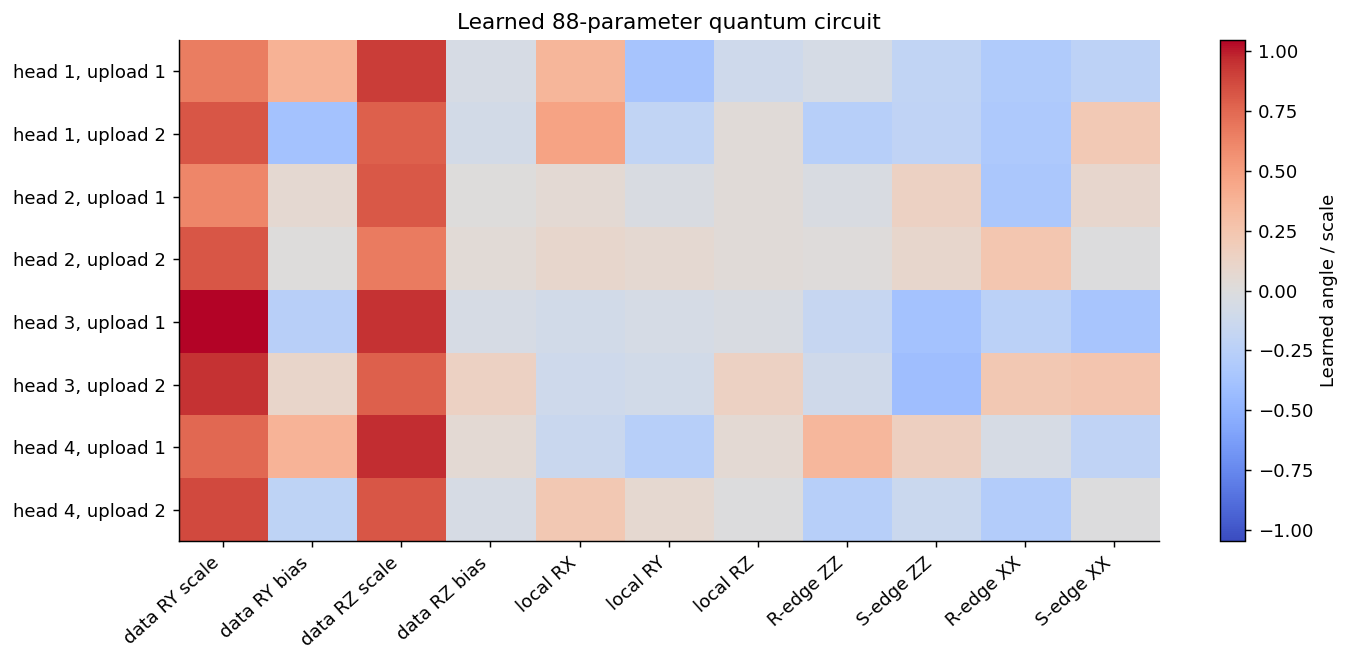

In [8]:
quantum_parameter_names = [
    "data RY scale", "data RY bias", "data RZ scale", "data RZ bias",
    "local RX", "local RY", "local RZ", "R-edge ZZ", "S-edge ZZ",
    "R-edge XX", "S-edge XX",
]
learned_circuit = np.asarray(model.core.params.detach().cpu().tolist(), dtype=np.float64).reshape(8, 11)
row_names = [f"head {head+1}, upload {upload+1}" for head in range(4) for upload in range(2)]
limit = max(abs(learned_circuit.min()), abs(learned_circuit.max()))
fig, ax = plt.subplots(figsize=(11, 5.2))
image = ax.imshow(learned_circuit, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
ax.set_xticks(np.arange(11), quantum_parameter_names, rotation=42, ha="right")
ax.set_yticks(np.arange(8), row_names)
ax.set_title("Learned 88-parameter quantum circuit")
fig.colorbar(image, ax=ax, label="Learned angle / scale")
fig.tight_layout()
save_paper_figure(fig, "fig05_learned_quantum_parameters")

## Sealed official-test evaluation

The following analysis reads only the immutable q2 prediction arrays and recomputes all central metrics. It neither performs model selection nor changes thresholds. The stored test result was produced on one NVIDIA H200 using bfloat16 inference, batch size 128, loader seed 42.

In [9]:
with np.load(TEST_PREDICTIONS) as bundle:
    test_labels = bundle["labels"].astype(np.int64)
    test_probabilities = bundle["probabilities"].astype(np.float64)
    test_predictions = bundle["predictions"].astype(np.int64)

official_result = json.loads(TEST_RESULT.read_text())
sealed_metrics = official_result["metrics"]["q2"]
validation_metrics = json.loads(VALIDATION_SUMMARY.read_text())["validation"]
training_history = json.loads(HISTORY.read_text())

assert len(test_labels) == 15_000
assert np.array_equal(np.bincount(test_labels, minlength=3), [5_000, 5_000, 5_000])
assert np.allclose(test_probabilities.sum(axis=1), 1.0, atol=1e-12)
assert np.array_equal(test_predictions, test_probabilities.argmax(axis=1))

def confusion_matrix_np(labels, predictions, classes=3):
    matrix = np.zeros((classes, classes), dtype=np.int64)
    np.add.at(matrix, (labels, predictions), 1)
    return matrix

def binary_roc(labels_binary, scores):
    order = np.argsort(-scores, kind="mergesort")
    y = labels_binary[order].astype(np.int64)
    s = scores[order]
    distinct = np.r_[np.where(np.diff(s))[0], y.size - 1]
    tp = np.cumsum(y)[distinct]
    fp = 1 + distinct - tp
    positives = y.sum()
    negatives = y.size - positives
    tpr = np.r_[0.0, tp / positives]
    fpr = np.r_[0.0, fp / negatives]
    return fpr, tpr, float(np.trapz(tpr, fpr))

def binary_pr(labels_binary, scores):
    order = np.argsort(-scores, kind="mergesort")
    y = labels_binary[order].astype(np.int64)
    s = scores[order]
    distinct = np.r_[np.where(np.diff(s))[0], y.size - 1]
    tp = np.cumsum(y)[distinct]
    fp = 1 + distinct - tp
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / max(y.sum(), 1)
    return np.r_[0.0, recall], np.r_[1.0, precision]

confusion = confusion_matrix_np(test_labels, test_predictions)
accuracy = float(np.mean(test_labels == test_predictions))
recalls = np.diag(confusion) / confusion.sum(axis=1)
precisions = np.diag(confusion) / confusion.sum(axis=0)
f1s = 2 * precisions * recalls / (precisions + recalls)
balanced_accuracy = float(recalls.mean())
macro_f1 = float(f1s.mean())
nll = float(-np.log(np.clip(test_probabilities[np.arange(len(test_labels)), test_labels], 1e-15, 1)).mean())
one_hot = np.eye(3)[test_labels]
brier = float(np.square(test_probabilities - one_hot).sum(axis=1).mean())
roc_data = [binary_roc(test_labels == cls, test_probabilities[:, cls]) for cls in range(3)]
macro_auc = float(np.mean([item[2] for item in roc_data]))

assert np.array_equal(confusion, np.asarray(sealed_metrics["confusion_matrix"]))
checks = {
    "accuracy": (accuracy, sealed_metrics["accuracy"]),
    "balanced_accuracy": (balanced_accuracy, sealed_metrics["balanced_accuracy"]),
    "macro_f1": (macro_f1, sealed_metrics["macro_f1"]),
    "macro_auc_ovr": (macro_auc, sealed_metrics["macro_auc_ovr"]),
    "nll": (nll, sealed_metrics["nll"]),
    "brier": (brier, sealed_metrics["brier"]),
}
for name, (recomputed, sealed) in checks.items():
    assert math.isclose(recomputed, sealed, rel_tol=0, abs_tol=2e-12), (name, recomputed, sealed)

overall_rows = [
    ("Training (best epoch)", 70_021, checkpoint_payload["record"]["train_accuracy"], None, None),
    ("Development validation", validation_metrics["samples"], validation_metrics["accuracy"],
     validation_metrics["macro_auc_ovr"], validation_metrics["macro_f1"]),
    ("Official test", sealed_metrics["samples"], accuracy, macro_auc, macro_f1),
]
overall_markdown = [
    "| Split | Images | Accuracy | Macro AUC | Macro F1 |",
    "|---|---:|---:|---:|---:|",
    *[
        f"| {name} | {images:,} | {acc:.4%} | "
        f"{('—' if auc is None else f'{auc:.6f}')} | "
        f"{('—' if f1 is None else f'{f1:.4%}')} |"
        for name, images, acc, auc, f1 in overall_rows
    ],
]
display(Markdown("\n".join(overall_markdown)))
print("Sealed q2 metric replay: PASSED")
print(f"Official test: {confusion.trace():,}/{confusion.sum():,} correct")
print("Wilson 95% accuracy interval:", sealed_metrics["accuracy_wilson95"])

| Split | Images | Accuracy | Macro AUC | Macro F1 |
|---|---:|---:|---:|---:|
| Training (best epoch) | 70,021 | 99.9586% | — | — |
| Development validation | 17,504 | 98.4746% | 0.998004 | 98.4810% |
| Official test | 15,000 | 98.3667% | 0.998369 | 98.3650% |

Sealed q2 metric replay: PASSED
Official test: 14,755/15,000 correct
Wilson 95% accuracy interval: {'confidence': 0.95, 'high': 0.9855747977727761, 'low': 0.981510867576589, 'samples': 15000, 'successes': 14755}


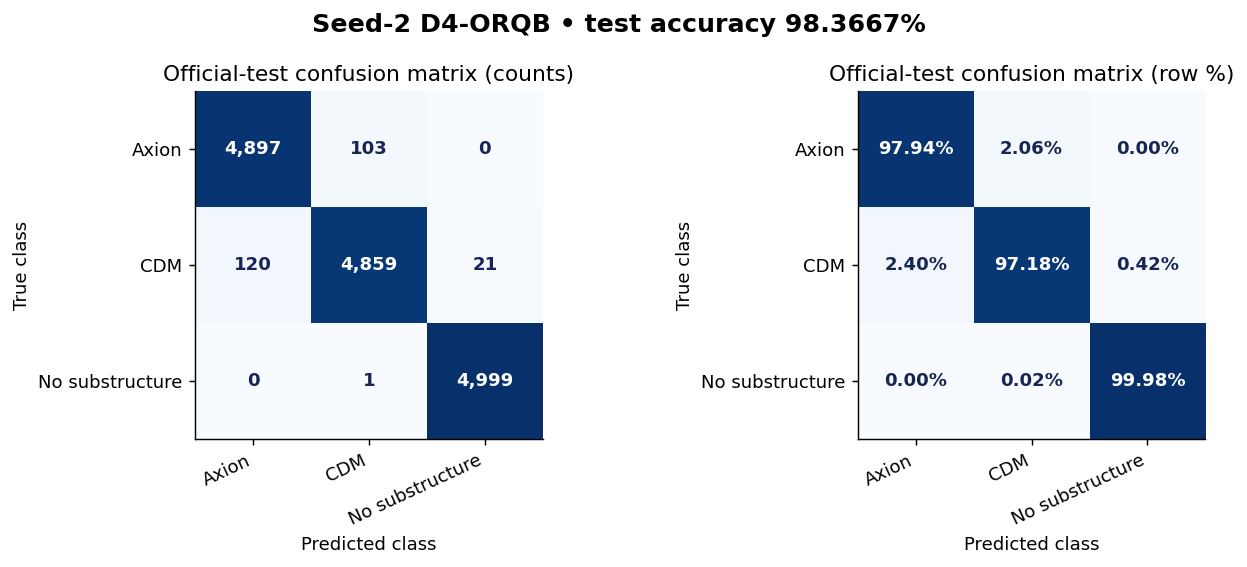

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
normalized = confusion / confusion.sum(axis=1, keepdims=True)
for ax, values, title, formatter in [
    (axes[0], confusion, "Official-test confusion matrix (counts)", lambda x: f"{int(x):,}"),
    (axes[1], normalized, "Official-test confusion matrix (row %)", lambda x: f"{100*x:.2f}%"),
]:
    im = ax.imshow(values, cmap="Blues", vmin=0)
    ax.set_xticks(range(3), CLASS_NAMES, rotation=25, ha="right")
    ax.set_yticks(range(3), CLASS_NAMES)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = values.max() * .55
    for i in range(3):
        for j in range(3):
            ax.text(j, i, formatter(values[i, j]), ha="center", va="center",
                    color="white" if values[i, j] > threshold else "#172554", weight="bold")
fig.suptitle(f"Seed-2 D4-ORQB • test accuracy {accuracy:.4%}", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig06_official_test_confusion")

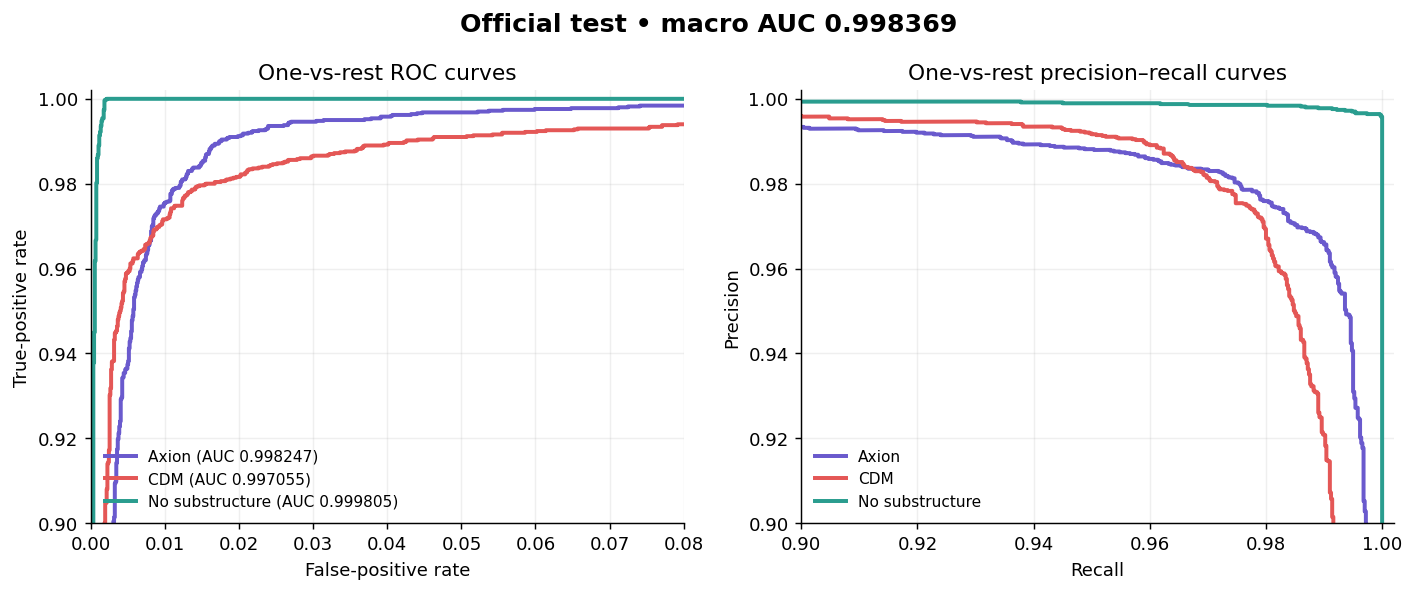

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for cls, (name, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, auc = roc_data[cls]
    axes[0].plot(fpr, tpr, color=color, lw=2.2, label=f"{name} (AUC {auc:.6f})")
    recall, precision = binary_pr(test_labels == cls, test_probabilities[:, cls])
    axes[1].plot(recall, precision, color=color, lw=2.2, label=name)
axes[0].plot([0, 1], [0, 1], "--", color="#94A3B8", lw=1)
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="One-vs-rest ROC curves", xlim=(0, .08), ylim=(.90, 1.002))
axes[1].set(xlabel="Recall", ylabel="Precision", title="One-vs-rest precision–recall curves", xlim=(.90, 1.002), ylim=(.90, 1.002))
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(loc="lower left", fontsize=8.5)
fig.suptitle(f"Official test • macro AUC {macro_auc:.6f}", fontsize=14, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig07_official_test_roc_pr")

| Class | Precision | Recall | F1 | AUC | Support |
|---|---:|---:|---:|---:|---:|
| Axion | 97.6081% | 97.9400% | 97.7738% | 0.998247 | 5,000 |
| CDM | 97.9045% | 97.1800% | 97.5409% | 0.997055 | 5,000 |
| No substructure | 99.5817% | 99.9800% | 99.7804% | 0.999805 | 5,000 |

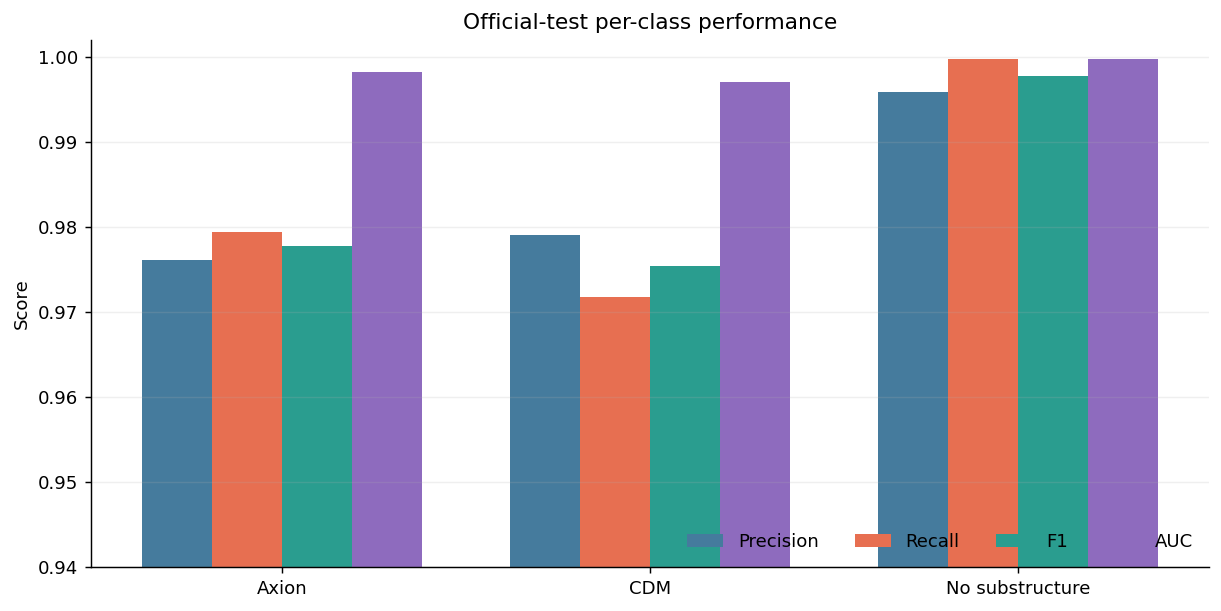

In [12]:
class_auc = np.array([item[2] for item in roc_data])
class_support = confusion.sum(axis=1)
class_markdown = [
    "| Class | Precision | Recall | F1 | AUC | Support |",
    "|---|---:|---:|---:|---:|---:|",
    *[
        f"| {CLASS_NAMES[i]} | {precisions[i]:.4%} | {recalls[i]:.4%} | "
        f"{f1s[i]:.4%} | {class_auc[i]:.6f} | {class_support[i]:,} |"
        for i in range(3)
    ],
]
display(Markdown("\n".join(class_markdown)))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
metric_names = ["Precision", "Recall", "F1", "AUC"]
x = np.arange(3)
width = .19
for offset, metric, color in zip(np.arange(4) - 1.5, metric_names, ["#457B9D", "#E76F51", "#2A9D8F", "#8E6BBE"]):
    values = {"Precision": precisions, "Recall": recalls, "F1": f1s, "AUC": class_auc}[metric]
    ax.bar(x + offset*width, values, width, label=metric, color=color)
ax.set_xticks(x, CLASS_NAMES)
ax.set_ylim(.94, 1.002)
ax.set_ylabel("Score")
ax.set_title("Official-test per-class performance")
ax.grid(axis="y", alpha=.2)
ax.legend(ncol=4, loc="lower right")
fig.tight_layout()
save_paper_figure(fig, "fig08_official_test_per_class")

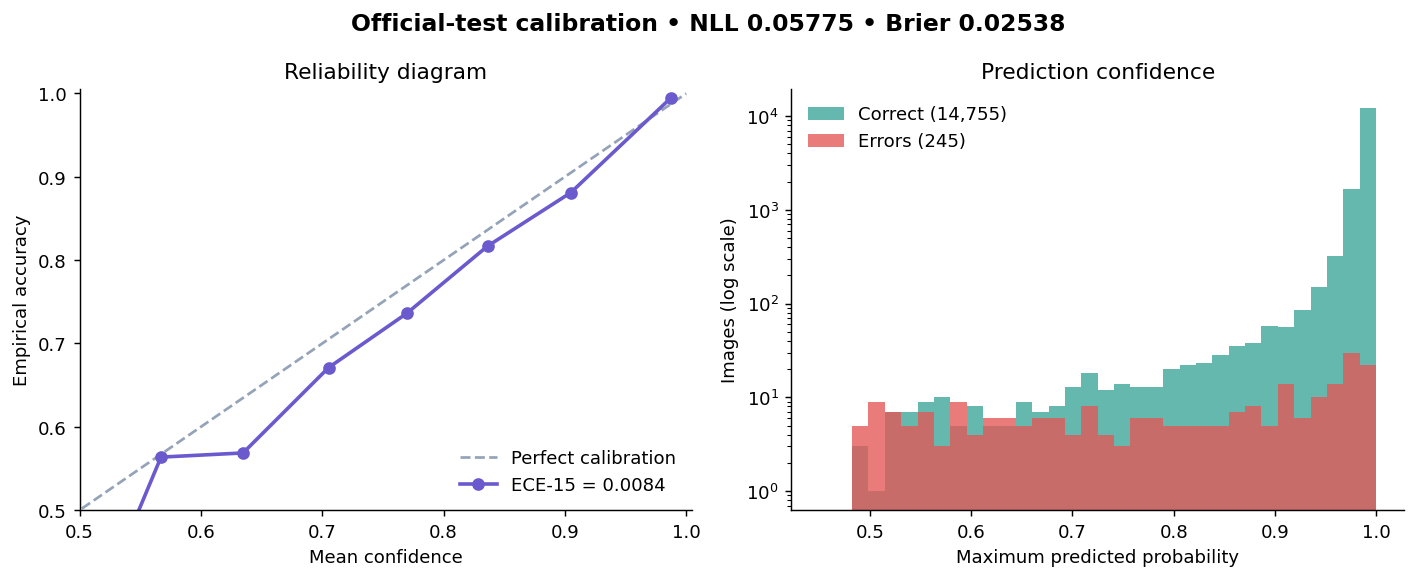

In [13]:
confidence = test_probabilities.max(axis=1)
correct = test_predictions == test_labels
edges = np.linspace(0, 1, 16)
bin_ids = np.minimum(np.digitize(confidence, edges[1:-1], right=True), 14)
bin_confidence, bin_accuracy, bin_count = [], [], []
for bin_id in range(15):
    mask = bin_ids == bin_id
    bin_count.append(int(mask.sum()))
    bin_confidence.append(float(confidence[mask].mean()) if mask.any() else np.nan)
    bin_accuracy.append(float(correct[mask].mean()) if mask.any() else np.nan)
ece = sum((count / len(correct)) * abs(acc - conf)
          for count, acc, conf in zip(bin_count, bin_accuracy, bin_confidence) if count)
assert math.isclose(ece, sealed_metrics["ece_15"], abs_tol=2e-12)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
valid = np.asarray(bin_count) > 0
axes[0].plot([0, 1], [0, 1], "--", color="#94A3B8", label="Perfect calibration")
axes[0].plot(np.asarray(bin_confidence)[valid], np.asarray(bin_accuracy)[valid], "o-", color="#6A5ACD", lw=2, label=f"ECE-15 = {ece:.4f}")
axes[0].set(xlabel="Mean confidence", ylabel="Empirical accuracy", title="Reliability diagram", xlim=(.5, 1.005), ylim=(.5, 1.005))
axes[0].legend(loc="lower right")
bins = np.linspace(.45, 1, 35)
axes[1].hist(confidence[correct], bins=bins, alpha=.72, color="#2A9D8F", label=f"Correct ({correct.sum():,})")
axes[1].hist(confidence[~correct], bins=bins, alpha=.78, color="#E45756", label=f"Errors ({(~correct).sum():,})")
axes[1].set_yscale("log")
axes[1].set(xlabel="Maximum predicted probability", ylabel="Images (log scale)", title="Prediction confidence")
axes[1].legend()
fig.suptitle(f"Official-test calibration • NLL {nll:.5f} • Brier {brier:.5f}", fontsize=13, weight="bold")
fig.tight_layout()
save_paper_figure(fig, "fig09_official_test_calibration")

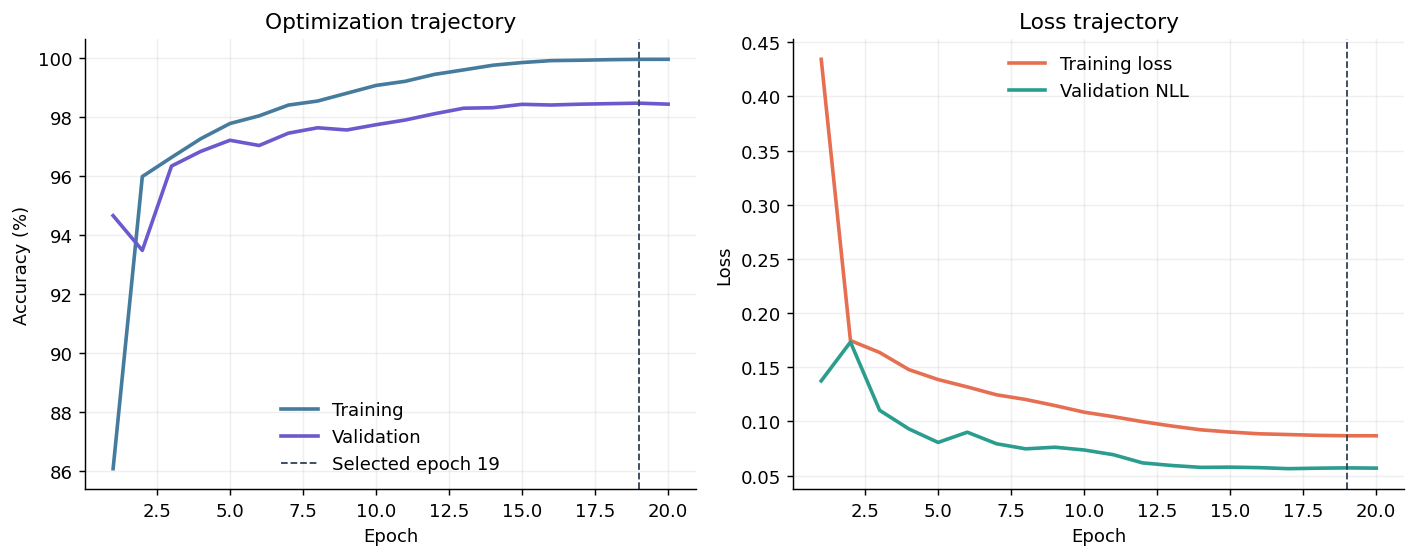

In [14]:
epochs = np.array([row["epoch"] for row in training_history])
train_accuracy = np.array([row["train_accuracy"] for row in training_history])
val_accuracy = np.array([row["validation"]["accuracy"] for row in training_history])
train_loss = np.array([row["train_loss"] for row in training_history])
val_nll = np.array([row["validation"]["nll"] for row in training_history])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(epochs, 100*train_accuracy, color="#457B9D", lw=2, label="Training")
axes[0].plot(epochs, 100*val_accuracy, color="#6A5ACD", lw=2, label="Validation")
axes[0].axvline(19, color="#334155", ls="--", lw=1, label="Selected epoch 19")
axes[0].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Optimization trajectory")
axes[0].legend()
axes[1].plot(epochs, train_loss, color="#E76F51", lw=2, label="Training loss")
axes[1].plot(epochs, val_nll, color="#2A9D8F", lw=2, label="Validation NLL")
axes[1].axvline(19, color="#334155", ls="--", lw=1)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="Loss trajectory")
axes[1].legend()
for ax in axes: ax.grid(alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig10_training_history")

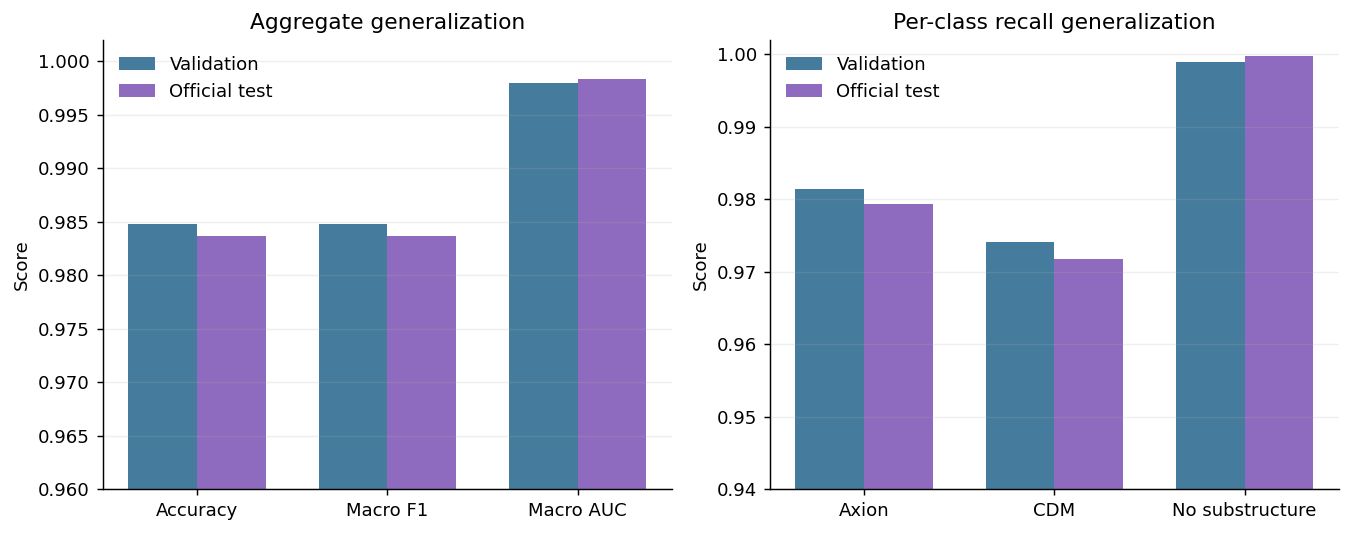

In [15]:
validation_per_class = validation_metrics["per_class"]
test_per_class = sealed_metrics["per_class"]
validation_recalls = np.array([validation_per_class[key]["recall"] for key in ("axion", "cdm", "no_sub")])
test_recalls = np.array([test_per_class[key]["recall"] for key in ("axion", "cdm", "no_sub")])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
aggregate_names = ["Accuracy", "Macro F1", "Macro AUC"]
validation_aggregate = [validation_metrics["accuracy"], validation_metrics["macro_f1"], validation_metrics["macro_auc_ovr"]]
test_aggregate = [sealed_metrics["accuracy"], sealed_metrics["macro_f1"], sealed_metrics["macro_auc_ovr"]]
x = np.arange(3)
axes[0].bar(x-.18, validation_aggregate, .36, label="Validation", color="#457B9D")
axes[0].bar(x+.18, test_aggregate, .36, label="Official test", color="#8E6BBE")
axes[0].set_xticks(x, aggregate_names)
axes[0].set_ylim(.96, 1.002)
axes[0].set_title("Aggregate generalization")
axes[0].legend()
axes[1].bar(x-.18, validation_recalls, .36, label="Validation", color="#457B9D")
axes[1].bar(x+.18, test_recalls, .36, label="Official test", color="#8E6BBE")
axes[1].set_xticks(x, CLASS_NAMES)
axes[1].set_ylim(.94, 1.002)
axes[1].set_title("Per-class recall generalization")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=.2)
fig.tight_layout()
save_paper_figure(fig, "fig11_validation_test_generalization")

## Paper-ready result summary

The selected model contains **245,221 trainable parameters**, including an **88-parameter quantum circuit** organized as four reusable eight-qubit heads with two data reuploads. Its learned orbit construction and tied circuit operations produce 48 D4-invariant quantum expectation features.

At the selected checkpoint (epoch 19), training accuracy was **99.9586%** and development-validation accuracy was **98.4746%**. The prospectively sealed official-test pass classified **14,755 of 15,000 images correctly**, corresponding to **98.3667% accuracy** with a Wilson 95% confidence interval of **98.1511–98.5575%**. Official-test macro AUC was **0.998369**, macro F1 was **0.983650**, NLL was **0.057747**, Brier score was **0.025378**, and ECE-15 was **0.008445**.

The remaining errors are concentrated in the physically difficult axion/CDM distinction. No-substructure recall is **99.98%**, while axion and CDM recall are **97.94%** and **97.18%**, respectively.

### Statements appropriate for the paper

- The architecture is structurally invariant to D4 rotations and reflections through orbit lifting, shared processing, symmetry-tied circuit operations, and invariant observable reduction.
- The quantum bottleneck is trained: its saved update norm is nonzero and the learned 88 circuit parameters are displayed above.
- The official-test result comes from one frozen checkpoint and one sealed test pass; test data were not used for checkpoint selection.
- The circuit result is based on ideal statevector simulation with analytic expectation values. It is not a claim of execution on noisy quantum hardware.
- Seed 2 is a fixed-backbone core replication initialized from the selected development backbone; it should not be described as a fully independent end-to-end training replication.

All PNG and vector PDF figures produced above are saved under the printed paper-figure directory. The same figures remain embedded in this executed notebook.

In [16]:
expected_stems = [f"fig{i:02d}" for i in range(1, 12)]
generated_png = sorted(FIGURE_DIR.glob("fig*.png"))
generated_pdf = sorted(FIGURE_DIR.glob("fig*.pdf"))
assert len(generated_png) == 11 and len(generated_pdf) == 11
final_audit = {
    "model": "D4-ORQB seed 2",
    "checkpoint_epoch": checkpoint_payload["epoch"],
    "trainable_parameters": model.parameter_count,
    "quantum_parameters": parameter_breakdown["Quantum circuit"],
    "validation_accuracy": validation_metrics["accuracy"],
    "official_test_accuracy": accuracy,
    "official_test_macro_auc": macro_auc,
    "official_test_macro_f1": macro_f1,
    "official_test_samples": len(test_labels),
    "artifact_hashes_verified": True,
    "live_inference_passed": True,
    "D4_invariance_max_logit_difference": max_logit_difference,
    "paper_png_figures": len(generated_png),
    "paper_pdf_figures": len(generated_pdf),
    "status": "PASS",
}
print(json.dumps(final_audit, indent=2))

{
  "model": "D4-ORQB seed 2",
  "checkpoint_epoch": 19,
  "trainable_parameters": 245221,
  "quantum_parameters": 88,
  "validation_accuracy": 0.9847463436928702,
  "official_test_accuracy": 0.9836666666666667,
  "official_test_macro_auc": 0.99836905,
  "official_test_macro_f1": 0.9836504167431105,
  "official_test_samples": 15000,
  "artifact_hashes_verified": true,
  "live_inference_passed": true,
  "D4_invariance_max_logit_difference": 9.5367431640625e-07,
  "paper_png_figures": 11,
  "paper_pdf_figures": 11,
  "status": "PASS"
}
